# Weather Prediction System using Machine Learning

This notebook builds a machine learning model to predict whether it will rain or not based on weather parameters.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('seattle-weather.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1461, 6)

First few rows:
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB
None

Statistical Summary:
       precipitation     temp_max   

## Step 3: Data Exploration and Preprocessing

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Missing values:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Column names:
['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']


In [4]:
# Check unique values in relevant columns
print("\nUnique weather types:")
print(df['weather'].value_counts())


Unique weather types:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


## Step 4: Feature Engineering and Target Definition

In [5]:
# Create binary target variable for rain prediction
# Assuming 'rain' (1) or other weather conditions (0)
df['RainTomorrow'] = (df['weather'] == 'rain').astype(int)

print("Rain distribution:")
print(df['RainTomorrow'].value_counts())
print(f"\nRain percentage: {(df['RainTomorrow'].sum() / len(df)) * 100:.2f}%")

Rain distribution:
RainTomorrow
0    820
1    641
Name: count, dtype: int64

Rain percentage: 43.87%


In [6]:
# Select features (based on available columns in the dataset)
# Using: temp_max, temp_min, precipitation as main features
feature_columns = ['temp_max', 'temp_min', 'precipitation']

# Check if these columns exist
print("Dataset columns:")
print(df.columns.tolist())

# Define features and target
X = df[feature_columns]
y = df['RainTomorrow']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature statistics:")
print(X.describe())

Dataset columns:
['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather', 'RainTomorrow']

Feature matrix shape: (1461, 3)
Target vector shape: (1461,)

Feature statistics:
          temp_max     temp_min  precipitation
count  1461.000000  1461.000000    1461.000000
mean     16.439083     8.234771       3.029432
std       7.349758     5.023004       6.680194
min      -1.600000    -7.100000       0.000000
25%      10.600000     4.400000       0.000000
50%      15.600000     8.300000       0.000000
75%      22.200000    12.200000       2.800000
max      35.600000    18.300000      55.900000


## Step 5: Split Dataset

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set rain distribution:")
print(y_train.value_counts())
print(f"\nTesting set rain distribution:")
print(y_test.value_counts())

Training set size: 1168
Testing set size: 293

Training set rain distribution:
RainTomorrow
0    656
1    512
Name: count, dtype: int64

Testing set rain distribution:
RainTomorrow
0    164
1    129
Name: count, dtype: int64


## Step 6: Train Machine Learning Models

### 6.1 Logistic Regression

In [8]:
# Train Logistic Regression model
model1 = LogisticRegression(random_state=42, max_iter=1000)
model1.fit(X_train, y_train)

print("Logistic Regression model trained!")

Logistic Regression model trained!


### 6.2 Decision Tree

In [9]:
# Train Decision Tree model
model2 = DecisionTreeClassifier(random_state=42, max_depth=10)
model2.fit(X_train, y_train)

print("Decision Tree model trained!")

Decision Tree model trained!


### 6.3 Random Forest

In [10]:
# Train Random Forest model
model3 = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model3.fit(X_train, y_train)

print("Random Forest model trained!")

Random Forest model trained!


## Step 7: Make Predictions

In [11]:
# Make predictions on test set
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

print("Predictions made for all models!")

Predictions made for all models!


## Step 8: Compare Model Accuracy

In [12]:
# Calculate accuracy scores
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

print("=" * 50)
print("MODEL ACCURACY COMPARISON")
print("=" * 50)
print(f"Logistic Regression Accuracy: {acc1:.4f} ({acc1*100:.2f}%)")
print(f"Decision Tree Accuracy: {acc2:.4f} ({acc2*100:.2f}%)")
print(f"Random Forest Accuracy: {acc3:.4f} ({acc3*100:.2f}%)")
print("=" * 50)

# Find the best model
accuracies = {'Logistic Regression': acc1, 'Decision Tree': acc2, 'Random Forest': acc3}
best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]
print(f"\nBest Model: {best_model_name} with accuracy {best_accuracy*100:.2f}%")

MODEL ACCURACY COMPARISON
Logistic Regression Accuracy: 0.8464 (84.64%)
Decision Tree Accuracy: 0.9317 (93.17%)
Random Forest Accuracy: 0.9386 (93.86%)

Best Model: Random Forest with accuracy 93.86%


## Step 9: Generate Confusion Matrices

In [13]:
# Generate confusion matrices
cm1 = confusion_matrix(y_test, pred1)
cm2 = confusion_matrix(y_test, pred2)
cm3 = confusion_matrix(y_test, pred3)

print("Confusion Matrix - Logistic Regression:")
print(cm1)
print("\nConfusion Matrix - Decision Tree:")
print(cm2)
print("\nConfusion Matrix - Random Forest:")
print(cm3)

Confusion Matrix - Logistic Regression:
[[149  15]
 [ 30  99]]

Confusion Matrix - Decision Tree:
[[156   8]
 [ 12 117]]

Confusion Matrix - Random Forest:
[[157   7]
 [ 11 118]]


## Step 10: Visualize Results

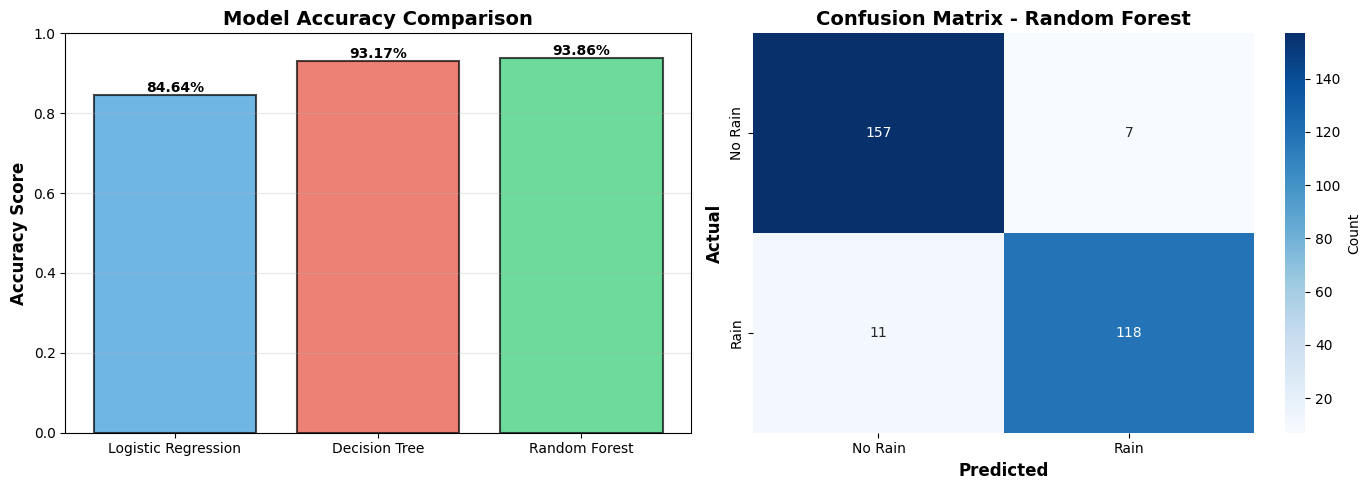

Visualization saved as 'model_comparison.png'


In [14]:
# Create accuracy comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for accuracy comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [acc1, acc2, acc3]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax1.bar(models, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.2%}', ha='center', va='bottom', fontweight='bold')

# Confusion matrix heatmap for best model (Random Forest)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'],
            cbar_kws={'label': 'Count'})
ax2.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'model_comparison.png'")

## Step 11: Generate Classification Reports

In [15]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT - RANDOM FOREST (BEST MODEL)")
print("="*60)
print(classification_report(y_test, pred3, target_names=['No Rain', 'Rain']))


CLASSIFICATION REPORT - RANDOM FOREST (BEST MODEL)
              precision    recall  f1-score   support

     No Rain       0.93      0.96      0.95       164
        Rain       0.94      0.91      0.93       129

    accuracy                           0.94       293
   macro avg       0.94      0.94      0.94       293
weighted avg       0.94      0.94      0.94       293



## Step 12: Save the Best Model

In [16]:
# Save the best performing model (Random Forest)
pickle.dump(model3, open('weather_model.pkl', 'wb'))
print("Model saved as 'weather_model.pkl'")

# Also save feature names for the app
pickle.dump(feature_columns, open('feature_columns.pkl', 'wb'))
print("Feature columns saved as 'feature_columns.pkl'")

Model saved as 'weather_model.pkl'
Feature columns saved as 'feature_columns.pkl'


## Step 13: Test Model Loading

In [17]:
# Load and test the saved model
loaded_model = pickle.load(open('weather_model.pkl', 'rb'))
loaded_features = pickle.load(open('feature_columns.pkl', 'rb'))

print("Model loaded successfully!")
print(f"Features: {loaded_features}")

# Test prediction with sample data
sample_data = np.array([[25.0, 15.0, 5.0]])  # temp_max, temp_min, precipitation
sample_prediction = loaded_model.predict(sample_data)
print(f"\nSample prediction: {sample_prediction[0]}")
print(f"Result: {'Rain Expected' if sample_prediction[0] == 1 else 'No Rain Expected'}")

Model loaded successfully!
Features: ['temp_max', 'temp_min', 'precipitation']

Sample prediction: 1
Result: Rain Expected
